# 🌍 Remote Work: ¿Revolución o Ilusión?
### *Salarios, Tecnología y Experiencia en el Sector Tech Global*
### *Stack Overflow Developer Survey 2021 & 2025*

---

**Autores:** [Nombre 1] · [Nombre 2]  
**Dataset:** Stack Overflow Developer Survey 2021 & 2025  
**Fecha:** Mayo 2026

---

## 🎯 Hipótesis

| # | Hipótesis |
|---|---|
| H1 | Los remotos en países emergentes cobran significativamente menos que los presenciales en países de alto coste → el remoto **no elimina** la brecha geográfica |
| H2 | Los desarrolladores con **más de 10 años de experiencia** trabajan en remoto con mayor frecuencia que los juniors |
| H3 | Los lenguajes modernos (Python, Rust, Go) tienen una proporción de teletrabajadores **significativamente mayor** que los lenguajes legacy |

---
> 📋 **Reparto de tareas**  
> **Persona A (Data Engineer):** Secciones 0–5 + Sección 7 (comparativa) + utils  
> **Persona B (Narrativa):** Secciones 6 (multivariante) + 8 (verificación) + Sección 9 (conclusiones) + README

---
## 0. 📦 Configuración del entorno
> *Persona A — ejecutar siempre en primer lugar*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# ── Rutas ─────────────────────────────────────────────────────────────────────
DATA_2025   = '../../src/data/survey_results_public.csv'
SCHEMA_2025 = '../../src/data/survey_results_schema.csv'
DATA_2021   = '../../src/data/survey_2021_public.csv'
IMG_DIR     = '../../src/imagenes/'
os.makedirs(IMG_DIR, exist_ok=True)

# ── Constantes globales ───────────────────────────────────────────────────────
REMOTE_MAP = {
    # Remote
    'Remote':                                                          'Remote',
    'Full remote':                                                     'Remote',
    # Hybrid (todas las variantes del survey 2025)
    'Hybrid (some remote, some in-person)':                            'Hybrid',
    'Hybrid (some remote, leans heavy to in-person)':                  'Hybrid',
    'Hybrid (some in-person, leans heavy to flexibility)':             'Hybrid',
    'Your choice (very flexible, you can come in when you want or just as needed)': 'Hybrid',
    # On-site
    'In-person':                                                       'On-site',
    'I work in-person most or all of the time':                        'On-site',
}
ORDEN_CAT = ['Remote', 'Hybrid', 'On-site']

PALETTE = {
    'remote':  '#2563EB',
    'hybrid':  '#7C3AED',
    'onsite':  '#DC2626',
    'neutral': '#6B7280',
    'accent':  '#059669',
}
COLORES = [PALETTE['remote'], PALETTE['hybrid'], PALETTE['onsite']]

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa', 'axes.grid': True,
    'grid.color': 'white', 'grid.linewidth': 1.2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11,
})

print('✅ Entorno configurado')

---
## 1. 📥 Carga de datos
> *Persona A*

In [2]:
# ── 2025 ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_2025, low_memory=False)
print(f'2025 → {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')

# ── 2021 (opcional — activa la sección comparativa) ───────────────────────────
try:
    df_raw_2021 = pd.read_csv(DATA_2021, low_memory=False)
    print(f'2021 → {df_raw_2021.shape[0]:,} filas × {df_raw_2021.shape[1]} columnas')
    HAY_2021 = True
except FileNotFoundError:
    print('⚠️  Dataset 2021 no encontrado — sección comparativa desactivada')
    HAY_2021 = False

2025 → 49,191 filas × 172 columnas
2021 → 83,439 filas × 48 columnas


In [3]:
# ── Selección de columnas relevantes ─────────────────────────────────────────
COLS_INTERES = [
    'ResponseId', 'Country', 'Employment', 'RemoteWork',
    'YearsCode', 'YearsCodePro', 'WorkExp',
    'ConvertedCompYearly', 'LanguageHaveWorkedWith',
    'DevType', 'OrgSize', 'EdLevel', 'JobSat', 'AISelect',
]
COLS_OK = [c for c in COLS_INTERES if c in df_raw.columns]
df = df_raw[COLS_OK].copy()
print(f'Columnas seleccionadas : {len(COLS_OK)}')
print(f'No encontradas         : {set(COLS_INTERES) - set(COLS_OK)}')

Columnas seleccionadas : 13
No encontradas         : {'YearsCodePro'}


---
## 2. 🔍 Data Understanding
> *Persona A*

In [4]:
resumen = pd.DataFrame({
    'Tipo':    df.dtypes,
    'Nulos':   df.isnull().sum(),
    '% Nulos': (df.isnull().mean() * 100).round(1),
    'Únicos':  df.nunique(),
    'Ejemplo': df.iloc[0],
})
resumen

,Tipo,Nulos,% Nulos,Únicos,Ejemplo
ResponseId,int64,0,0.0,49191,1
Country,str,13754,28.0,177,Ukraine
Employment,str,852,1.7,6,Employed
RemoteWork,str,15411,31.3,5,Remote
YearsCode,float64,6149,12.5,78,14.0
WorkExp,float64,6298,12.8,72,8.0
ConvertedCompYearly,float64,25244,51.3,6237,61256.0
LanguageHaveWorkedWith,str,17520,35.6,15478,Bash/Shell (all shells);Dart;SQL
DevType,str,5511,11.2,32,"Developer, mobile"
OrgSize,str,15013,30.5,9,20 to 99 employees


In [5]:
print('Valores únicos en RemoteWork:')
print(df['RemoteWork'].value_counts(dropna=False))

Valores únicos en RemoteWork:
RemoteWork
NaN                                                                             15411
Remote                                                                          10931
Hybrid (some remote, leans heavy to in-person)                                   6732
In-person                                                                        6042
Hybrid (some in-person, leans heavy to flexibility)                              5831
Your choice (very flexible, you can come in when you want or just as needed)     4244
Name: count, dtype: int64


---
## 3. 🧹 Limpieza y preprocesado
> *Persona A — feature/limpieza*

> ⚠️ **Orden crítico:** filtrar empleados → columnas derivadas (`RemoteCategory`, `ExpBand`) → **al final** crear `df_sal`

In [ ]:
# ── 3.1 Filtrar empleados activos ─────────────────────────────────────────────
# En el survey 2025 Employment usa valores cortos: 'Employed', 'Independent', etc.
# Primero vemos qué valores hay exactamente
print('Valores únicos Employment:')
print(df['Employment'].value_counts(dropna=False))

empleo_valido = ['Employed', 'Independent contractor', 'freelancer', 'self-employed']

if 'Employment' in df.columns:
    mask = df['Employment'].fillna('').apply(
        lambda x: any(e.lower() in x.lower() for e in empleo_valido)
    )
    df = df[mask].copy()
print(f'\n✅ Tras filtrar empleados: {len(df):,} registros')


In [7]:
# ── 3.2 Limpiar experiencia + alias estándar YearsCodePro ────────────────────
def limpiar_years(col):
    return (
        col.replace('Less than 1 year', 0)
           .replace('More than 50 years', 51)
           .pipe(pd.to_numeric, errors='coerce')
    )

for col in ['YearsCode', 'YearsCodePro', 'WorkExp']:
    if col in df.columns:
        df[col] = limpiar_years(df[col])

# Columna de experiencia profesional disponible en este survey
EXP_COL = next((c for c in ['WorkExp', 'YearsCodePro', 'YearsCode'] if c in df.columns), None)

# Alias estándar: todo el notebook usa 'YearsCodePro'
if EXP_COL and EXP_COL != 'YearsCodePro':
    df['YearsCodePro'] = df[EXP_COL]

print(f'Columna de experiencia usada: {EXP_COL}')
print(df['YearsCodePro'].describe().round(1))

Columna de experiencia usada: WorkExp
count    6265.0
mean       17.0
std        11.6
min         1.0
25%         8.0
50%        15.0
75%        25.0
max       100.0
Name: YearsCodePro, dtype: float64


In [8]:
# ── 3.3 Crear RemoteCategory ──────────────────────────────────────────────────
# ANTES de crear df_sal para que la columna quede en ambos DataFrames
df['RemoteCategory'] = df['RemoteWork'].map(REMOTE_MAP)
print('RemoteCategory — distribución:')
print(df['RemoteCategory'].value_counts(dropna=False))

RemoteCategory — distribución:
RemoteCategory
NaN        5170
Remote     1390
On-site     148
Name: count, dtype: int64


In [9]:
# ── 3.4 Duplicados y nulos críticos ──────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f'Duplicados encontrados: {n_dup}')
if n_dup > 0:
    df = df.drop_duplicates()
    print(f'✅ Eliminados. Registros restantes: {len(df):,}')

# Resumen de nulos en columnas clave
cols_clave = ['RemoteWork', 'ConvertedCompYearly', 'Country', 'YearsCodePro']
print('\nNulos en columnas clave:')
print(df[[c for c in cols_clave if c in df.columns]].isnull().sum())

Duplicados encontrados: 0

Nulos en columnas clave:
RemoteWork             4381
ConvertedCompYearly    3658
Country                1774
YearsCodePro            443
dtype: int64


In [10]:
# ── 3.5 Crear ExpBand ─────────────────────────────────────────────────────────
bins   = [-1, 2, 5, 10, 20, 100]
labels = ['Junior (0-2)', 'Mid (3-5)', 'Senior (6-10)', 'Staff (11-20)', 'Principal (20+)']
df['ExpBand'] = pd.cut(df['YearsCodePro'], bins=bins, labels=labels)
print('ExpBand — distribución:')
print(df['ExpBand'].value_counts().sort_index())

ExpBand — distribución:
ExpBand
Junior (0-2)        361
Mid (3-5)           720
Senior (6-10)      1226
Staff (11-20)      1991
Principal (20+)    1967
Name: count, dtype: int64


In [11]:
# ── 3.6 Crear df_sal — SIEMPRE al final del preprocesado ─────────────────────
# Al crearlo aquí hereda RemoteCategory y ExpBand automáticamente
df_sal = df.dropna(subset=['ConvertedCompYearly']).copy()
df_sal = df_sal[
    (df_sal['ConvertedCompYearly'] >= 1_000) &
    (df_sal['ConvertedCompYearly'] <= 500_000)
].copy()

print(f'Registros con salario válido : {len(df_sal):,}')
print(f'Mediana salarial global       : ${df_sal["ConvertedCompYearly"].median():,.0f}')
print(f'RemoteCategory presente       : {"RemoteCategory" in df_sal.columns} ✅')
print(f'ExpBand presente              : {"ExpBand" in df_sal.columns} ✅')

Registros con salario válido : 2,882
Mediana salarial global       : $75,410
RemoteCategory presente       : True ✅
ExpBand presente              : True ✅


In [12]:
# ── 3.7 Guardar dataset limpio ────────────────────────────────────────────────
df.to_csv('../../src/data/survey_clean.csv', index=False)
print(f'✅ Guardado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

✅ Guardado: 6,708 filas × 16 columnas


---
## 4. 📊 Análisis Univariante
> *Persona A — feature/analisis*

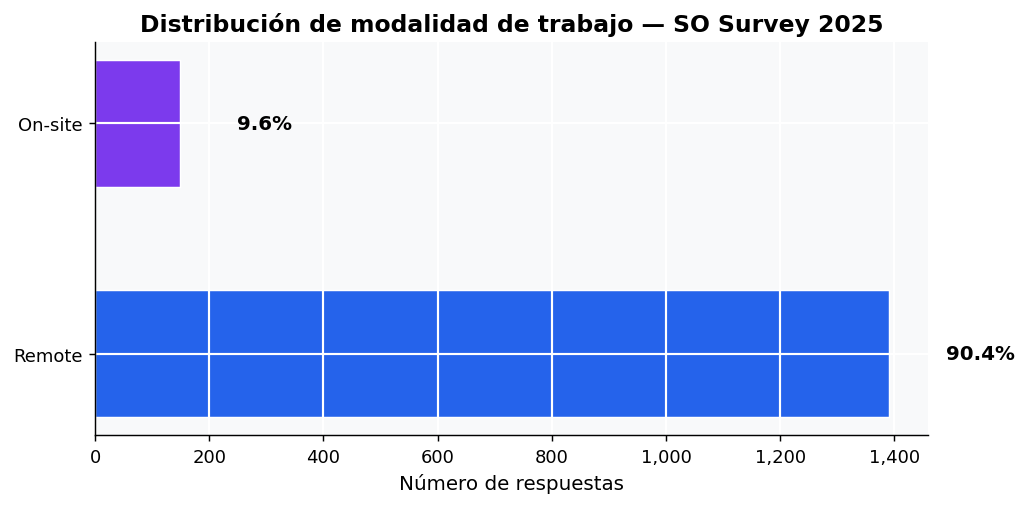

In [13]:
# ── 4.1 Distribución de modalidad de trabajo ──────────────────────────────────
remote_counts = df['RemoteCategory'].value_counts(dropna=True)
pct = remote_counts / remote_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    remote_counts.index, remote_counts.values,
    color=COLORES[:len(remote_counts)], edgecolor='white', linewidth=0.8, height=0.55
)
for bar, p in zip(bars, pct):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{p:.1f}%', va='center', fontweight='bold', fontsize=11)
ax.set_title('Distribución de modalidad de trabajo — SO Survey 2025', fontweight='bold')
ax.set_xlabel('Número de respuestas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'{IMG_DIR}01_distribucion_remoto.png', bbox_inches='tight')
plt.show()

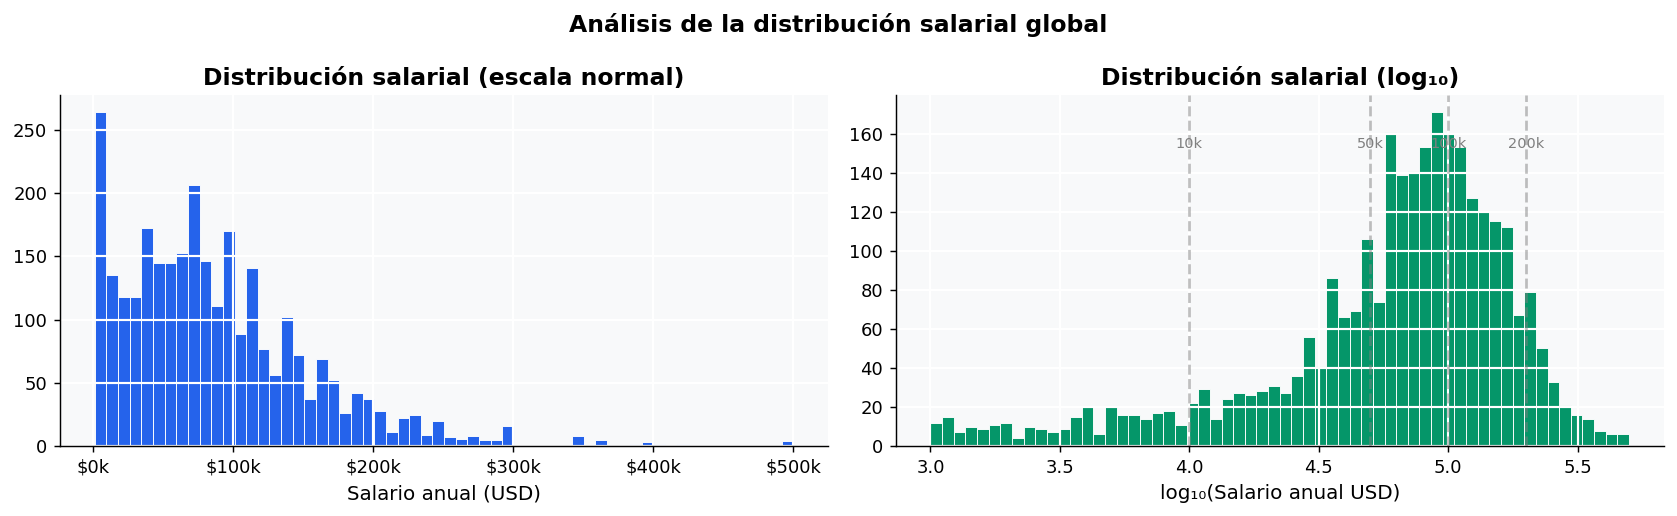

In [14]:
# ── 4.2 Distribución salarial (normal + log) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_sal['ConvertedCompYearly'], bins=60,
             color=PALETTE['remote'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribución salarial (escala normal)', fontweight='bold')
axes[0].set_xlabel('Salario anual (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))

log_sal = np.log10(df_sal['ConvertedCompYearly'])
axes[1].hist(log_sal, bins=60, color=PALETTE['accent'], edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribución salarial (log₁₀)', fontweight='bold')
axes[1].set_xlabel('log₁₀(Salario anual USD)')
for val, lbl in [(4, '10k'), (4.7, '50k'), (5, '100k'), (5.3, '200k')]:
    axes[1].axvline(val, color='gray', linestyle='--', alpha=0.5)
    axes[1].text(val, axes[1].get_ylim()[1]*0.85, lbl, ha='center', fontsize=8, color='gray')

plt.suptitle('Análisis de la distribución salarial global', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}02_distribucion_salarios.png', bbox_inches='tight')
plt.show()

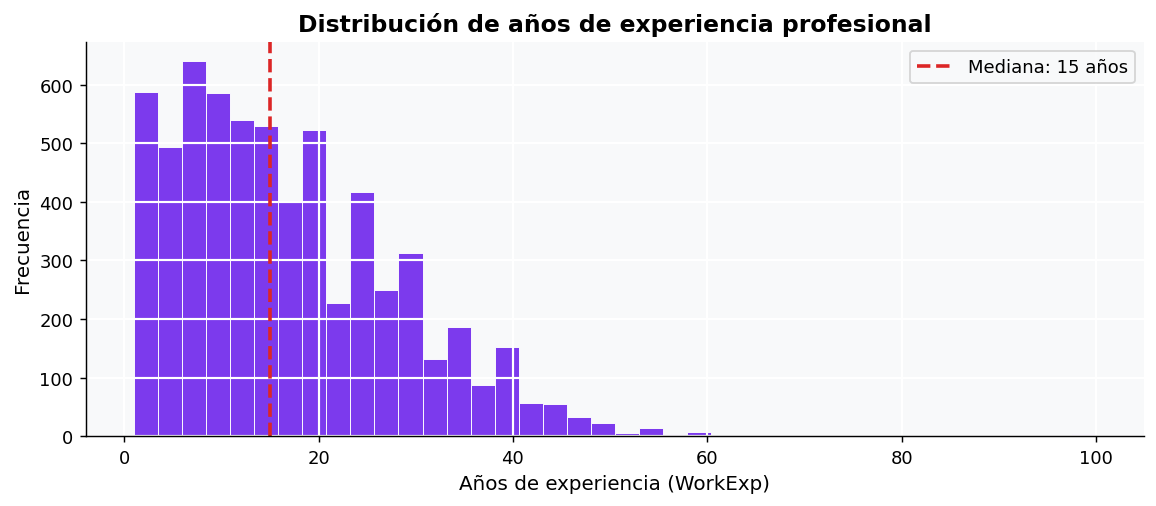

In [15]:
# ── 4.3 Distribución de experiencia profesional ───────────────────────────────
df_exp = df.dropna(subset=['YearsCodePro'])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_exp['YearsCodePro'], bins=40, color=PALETTE['hybrid'],
        edgecolor='white', linewidth=0.5)
mediana = df_exp['YearsCodePro'].median()
ax.axvline(mediana, color=PALETTE['onsite'], linestyle='--', linewidth=2,
           label=f'Mediana: {mediana:.0f} años')
ax.set_title('Distribución de años de experiencia profesional', fontweight='bold')
ax.set_xlabel(f'Años de experiencia ({EXP_COL})')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig(f'{IMG_DIR}03_distribucion_experiencia.png', bbox_inches='tight')
plt.show()

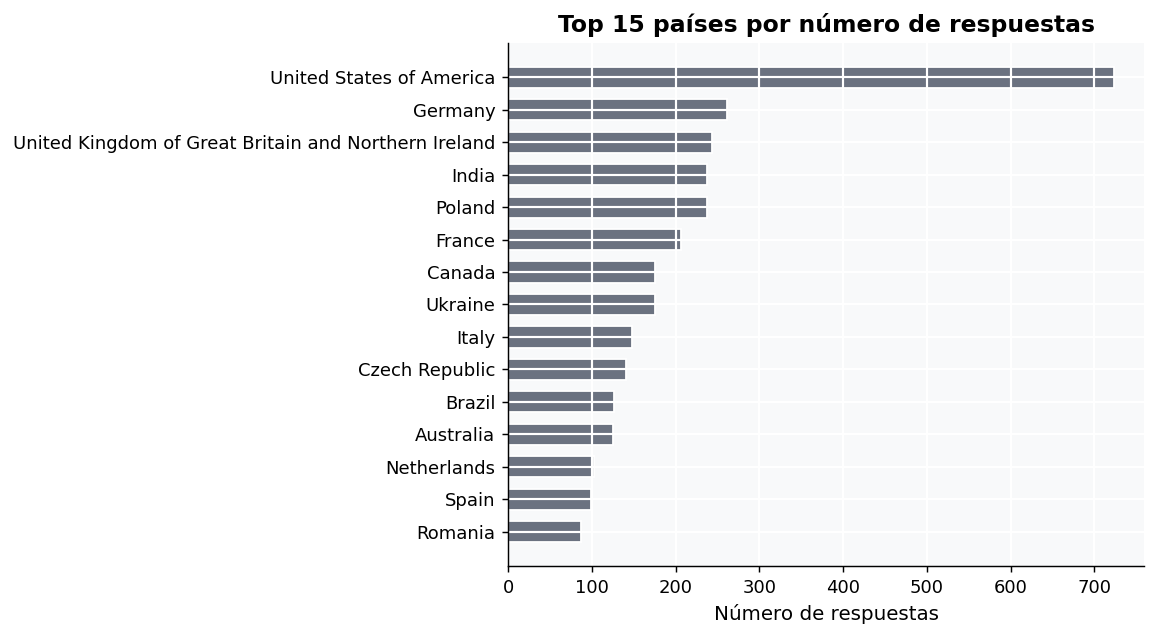

In [16]:
# ── 4.4 Top 15 países por número de respuestas ───────────────────────────────
if 'Country' in df.columns:
    top_paises = df['Country'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(top_paises.index[::-1], top_paises.values[::-1],
            color=PALETTE['neutral'], edgecolor='white', height=0.65)
    ax.set_title('Top 15 países por número de respuestas', fontweight='bold')
    ax.set_xlabel('Número de respuestas')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig(f'{IMG_DIR}04_top_paises_respuestas.png', bbox_inches='tight')
    plt.show()

---
## 5. 📊 Análisis Bivariante
> *Persona A — feature/analisis*

### 🔵 H1 — ¿El trabajo remoto democratiza los salarios o los penaliza?

In [17]:
# ── H1.1 Estadísticas salariales por modalidad ───────────────────────────────
df_h1 = df_sal.dropna(subset=['RemoteCategory']).copy()

sal_remote = df_h1.groupby('RemoteCategory')['ConvertedCompYearly'].agg(
    mediana='median', media='mean', n='count',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
).round(0)
print('💰 Salario por modalidad (USD anuales):')
print(sal_remote.to_string())

💰 Salario por modalidad (USD anuales):
                mediana    media    n      p25       p75
RemoteCategory                                          
On-site         40599.0  59566.0   54  10556.0   92949.0
Remote          61919.0  78856.0  677  25000.0  108913.0


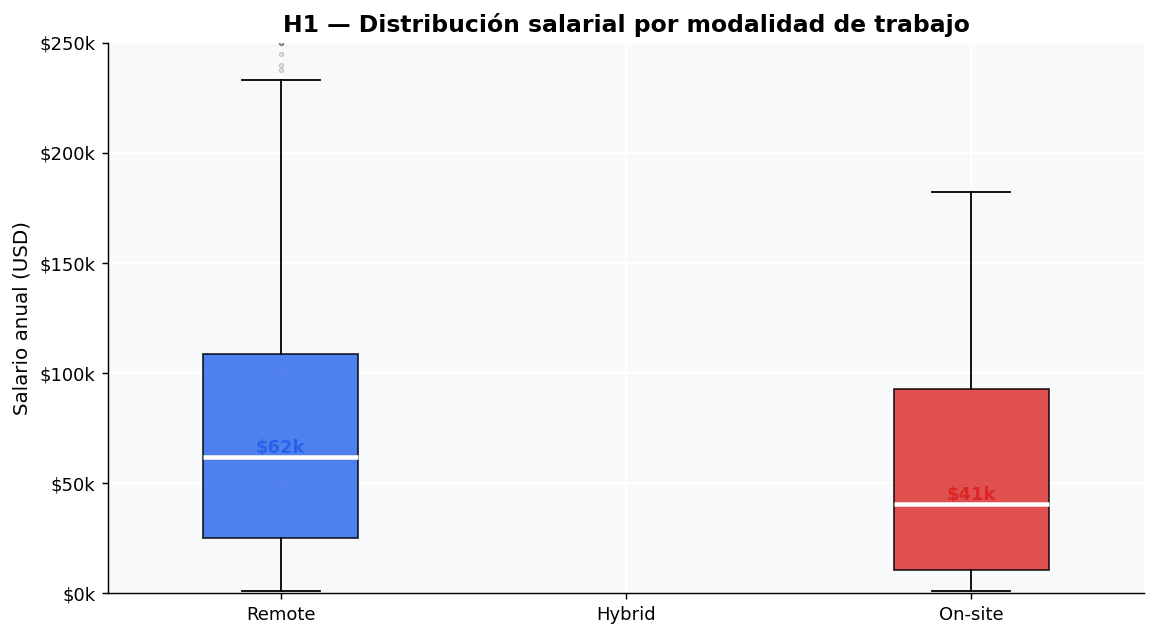

In [18]:
# ── H1.2 Boxplot salario × modalidad ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
data_box = [df_h1[df_h1['RemoteCategory'] == cat]['ConvertedCompYearly'].dropna()
            for cat in ORDEN_CAT]

bp = ax.boxplot(
    data_box, labels=ORDEN_CAT, patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    flierprops=dict(marker='o', alpha=0.2, markersize=2), widths=0.45
)
for patch, color in zip(bp['boxes'], COLORES):
    patch.set_facecolor(color); patch.set_alpha(0.8)

for i, (cat, color) in enumerate(zip(ORDEN_CAT, COLORES), start=1):
    med = df_h1[df_h1['RemoteCategory'] == cat]['ConvertedCompYearly'].median()
    ax.text(i, med + 2000, f'${med/1000:.0f}k', ha='center',
            fontweight='bold', color=color, fontsize=10)

ax.set_title('H1 — Distribución salarial por modalidad de trabajo', fontweight='bold')
ax.set_ylabel('Salario anual (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))
ax.set_ylim(0, 250_000)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}05_h1_salario_remoto_boxplot.png', bbox_inches='tight')
plt.show()

In [19]:
# ── H1.3 Test Kruskal-Wallis ──────────────────────────────────────────────────
grupos = [df_h1[df_h1['RemoteCategory'] == cat]['ConvertedCompYearly'].dropna()
          for cat in ORDEN_CAT]
stat, pvalue = stats.kruskal(*grupos)
print(f'🧪 Kruskal-Wallis  H={stat:.2f}  p={pvalue:.4e}')
print(f'→ {"Diferencias SIGNIFICATIVAS" if pvalue < 0.05 else "Sin diferencias significativas"} (α=0.05)')

🧪 Kruskal-Wallis  H=nan  p=nan
→ Sin diferencias significativas (α=0.05)


### 🔴 H1b — ¿Reduce el remoto la brecha salarial geográfica?

In [20]:
# ── H1b.1 Clasificación geoeconómica de países ────────────────────────────────
PAISES_ALTO = [
    'United States of America', 'United Kingdom', 'Germany', 'Switzerland',
    'Australia', 'Canada', 'Netherlands', 'Sweden', 'Denmark', 'Norway',
    'France', 'Austria', 'Finland', 'New Zealand', 'Israel'
]
PAISES_EMERGENTES = [
    'India', 'Brazil', 'Poland', 'Ukraine', 'Turkey', 'Argentina',
    'Romania', 'Pakistan', 'Egypt', 'Nigeria', 'Colombia', 'Mexico',
    'Indonesia', 'Vietnam', 'Bangladesh'
]

def clasificar_pais(p):
    if p in PAISES_ALTO:       return 'Alto ingreso'
    if p in PAISES_EMERGENTES: return 'Emergente'
    return None

if 'Country' in df_sal.columns:
    df_h4 = df_sal.copy()
    df_h4['GrupoGeo'] = df_h4['Country'].apply(clasificar_pais)
    df_h4 = df_h4.dropna(subset=['GrupoGeo', 'RemoteCategory'])
    print(f'Registros para análisis geográfico: {len(df_h4):,}')
    print(df_h4.groupby(['GrupoGeo', 'RemoteCategory'])['ConvertedCompYearly'].median().unstack().round(0))

Registros para análisis geográfico: 477
RemoteCategory  On-site   Remote
GrupoGeo                        
Alto ingreso    92995.0  76804.0
Emergente        6586.0  43689.0


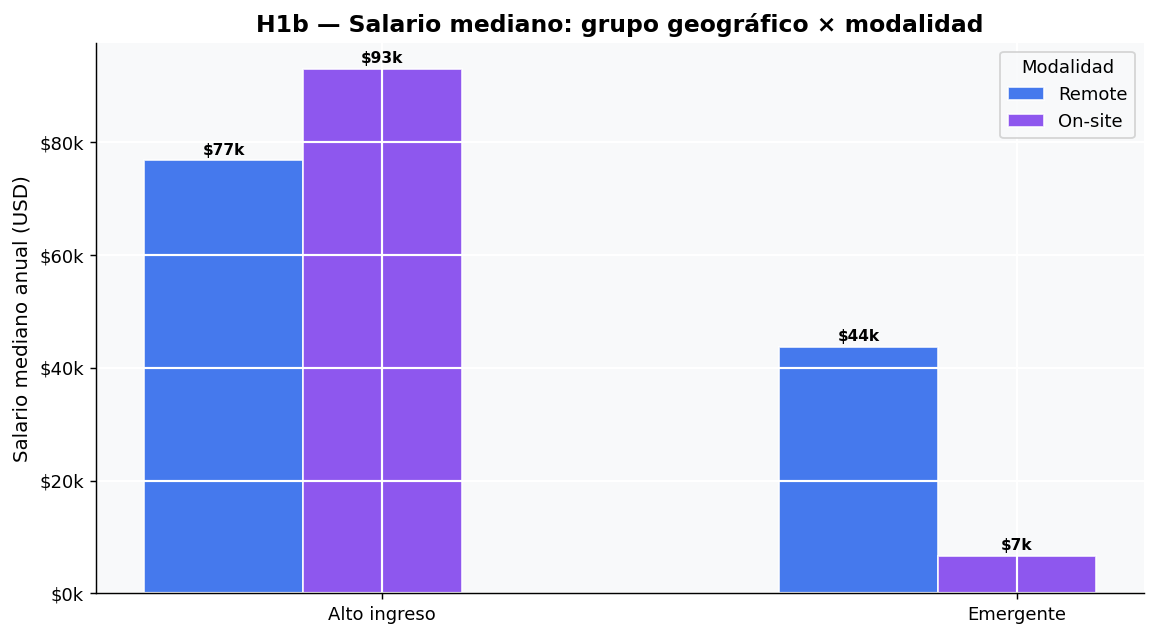

In [21]:
# ── H1b.2 Barras agrupadas: salario por grupo geo × modalidad ─────────────────
if 'Country' in df_sal.columns and len(df_h4) > 0:
    pivot_h4 = (
        df_h4.groupby(['GrupoGeo', 'RemoteCategory'])['ConvertedCompYearly']
        .median().unstack()
    )
    cols = [c for c in ORDEN_CAT if c in pivot_h4.columns]
    pivot_h4 = pivot_h4[cols]

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(pivot_h4.index))
    for i, (col, color) in enumerate(zip(cols, COLORES)):
        bars = ax.bar(x + i*0.25, pivot_h4[col], width=0.25,
                      label=col, color=color, alpha=0.85, edgecolor='white')
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 500,
                        f'${h/1000:.0f}k', ha='center', va='bottom',
                        fontsize=8.5, fontweight='bold')
    ax.set_xticks(x + 0.25)
    ax.set_xticklabels(pivot_h4.index)
    ax.set_title('H1b — Salario mediano: grupo geográfico × modalidad', fontweight='bold')
    ax.set_ylabel('Salario mediano anual (USD)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))
    ax.legend(title='Modalidad')
    plt.tight_layout()
    plt.savefig(f'{IMG_DIR}06_h1b_brecha_geografica.png', bbox_inches='tight')
    plt.show()

### 🟣 H2 — ¿Más experiencia = más trabajo remoto?

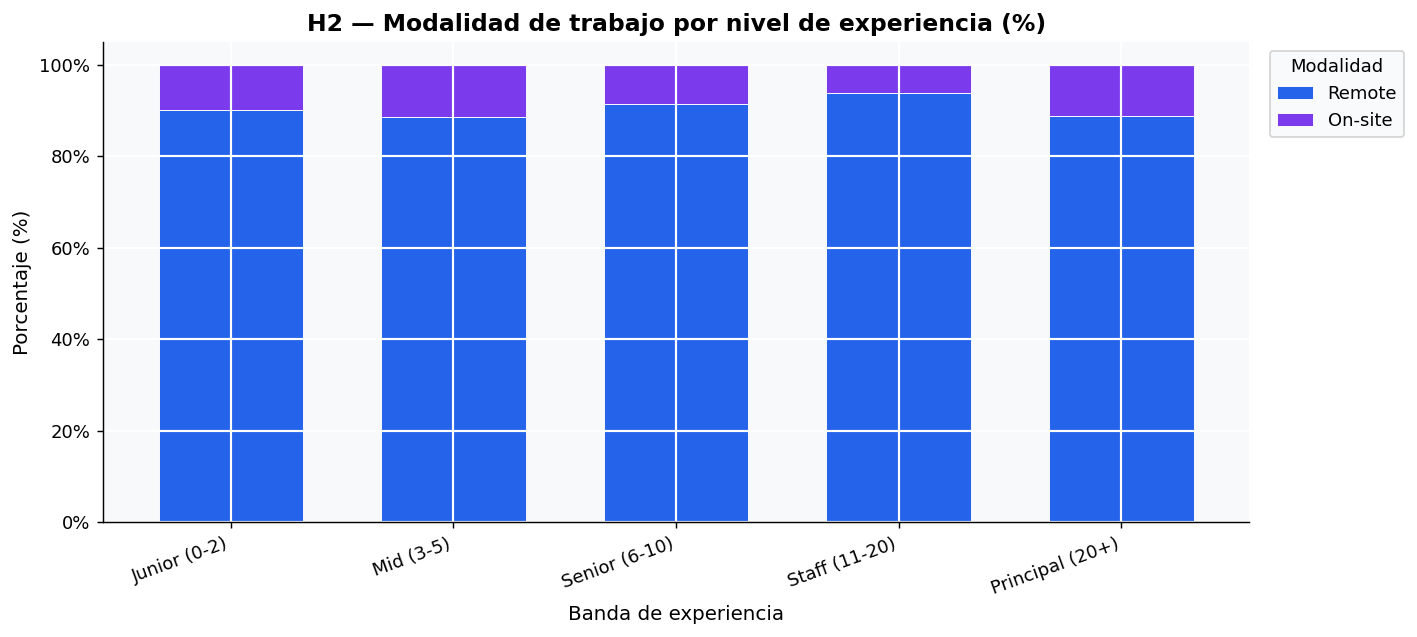

In [22]:
# ── H2.1 Proporción de modalidad por banda de experiencia ────────────────────
df_h2 = df.dropna(subset=['RemoteCategory', 'ExpBand']).copy()

pivot_exp = (
    df_h2.groupby(['ExpBand', 'RemoteCategory'], observed=True)
    .size().unstack(fill_value=0)
    .apply(lambda row: row / row.sum() * 100, axis=1)
)
cols_order = [c for c in ORDEN_CAT if c in pivot_exp.columns]
pivot_exp  = pivot_exp[cols_order]

fig, ax = plt.subplots(figsize=(11, 5))
pivot_exp.plot(
    kind='bar', stacked=True, ax=ax,
    color=COLORES[:len(cols_order)], edgecolor='white', linewidth=0.5, width=0.65
)
ax.set_title('H2 — Modalidad de trabajo por nivel de experiencia (%)', fontweight='bold')
ax.set_xlabel('Banda de experiencia')
ax.set_ylabel('Porcentaje (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Modalidad', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig(f'{IMG_DIR}07_h2_experiencia_remoto.png', bbox_inches='tight')
plt.show()

### 🟢 H3 — ¿Qué tecnologías dan más probabilidades de trabajo remoto?

In [23]:
# ── H3.1 Explode: una fila por lenguaje ──────────────────────────────────────
if 'LanguageHaveWorkedWith' in df.columns:
    df_lang = df[['ResponseId', 'RemoteCategory', 'LanguageHaveWorkedWith']].dropna().copy()
    df_lang['Lang'] = df_lang['LanguageHaveWorkedWith'].str.split(';')
    df_lang = df_lang.explode('Lang')
    df_lang['Lang'] = df_lang['Lang'].str.strip()
    print(f'Registros tras explode: {len(df_lang):,}')
    print(df_lang['Lang'].value_counts().head(10))

Registros tras explode: 7,272
Lang
JavaScript                 844
HTML/CSS                   791
SQL                        687
Python                     598
TypeScript                 544
Bash/Shell (all shells)    494
PHP                        343
C#                         271
C++                        251
Java                       247
Name: count, dtype: int64


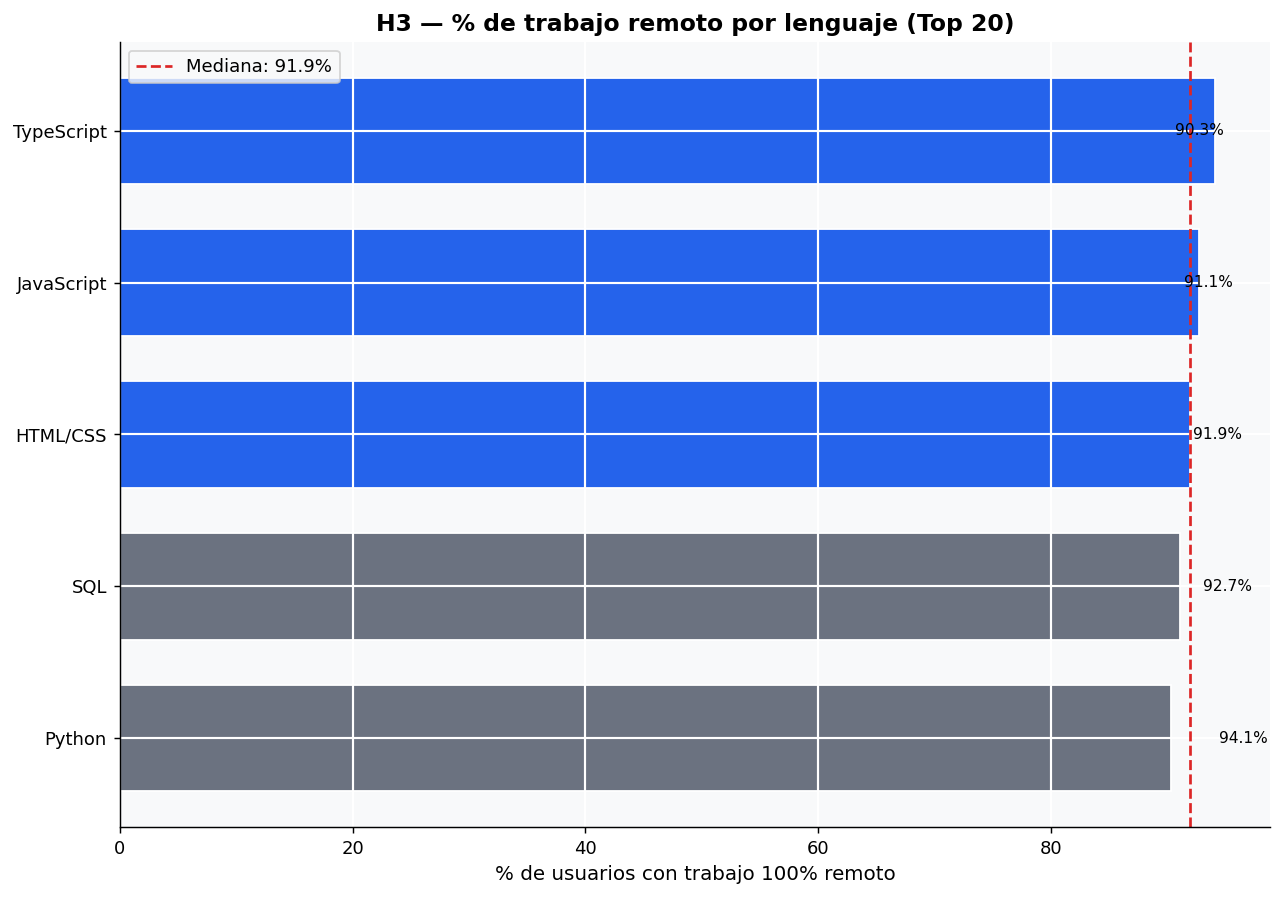

In [24]:
# ── H3.2 % de trabajo remoto por lenguaje (Top 20) ───────────────────────────
if 'LanguageHaveWorkedWith' in df.columns:
    top_langs   = df_lang['Lang'].value_counts()
    top_langs   = top_langs[top_langs >= 500].index.tolist()
    df_lang_top = df_lang[df_lang['Lang'].isin(top_langs)].copy()

    remote_by_lang = (
        df_lang_top.groupby('Lang')['RemoteCategory']
        .apply(lambda x: (x == 'Remote').sum() / len(x) * 100)
        .sort_values(ascending=False).round(1)
    )
    top20 = remote_by_lang.head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = [PALETTE['remote'] if v >= remote_by_lang.median() else PALETTE['neutral']
              for v in top20.values]
    bars = ax.barh(top20.index[::-1], top20.values[::-1],
                   color=colors[::-1], edgecolor='white', height=0.7)
    ax.axvline(remote_by_lang.median(), color=PALETTE['onsite'], linestyle='--', linewidth=1.5,
               label=f'Mediana: {remote_by_lang.median():.1f}%')
    for bar, val in zip(bars[::-1], top20.values[::-1]):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8.5)
    ax.set_title('H3 — % de trabajo remoto por lenguaje (Top 20)', fontweight='bold')
    ax.set_xlabel('% de usuarios con trabajo 100% remoto')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{IMG_DIR}08_h3_remoto_por_lenguaje.png', bbox_inches='tight')
    plt.show()

---
## 6. 📊 Análisis Multivariante
> *Persona B — feature/analisis*

Combinamos varias variables para identificar segmentos y patrones complejos.

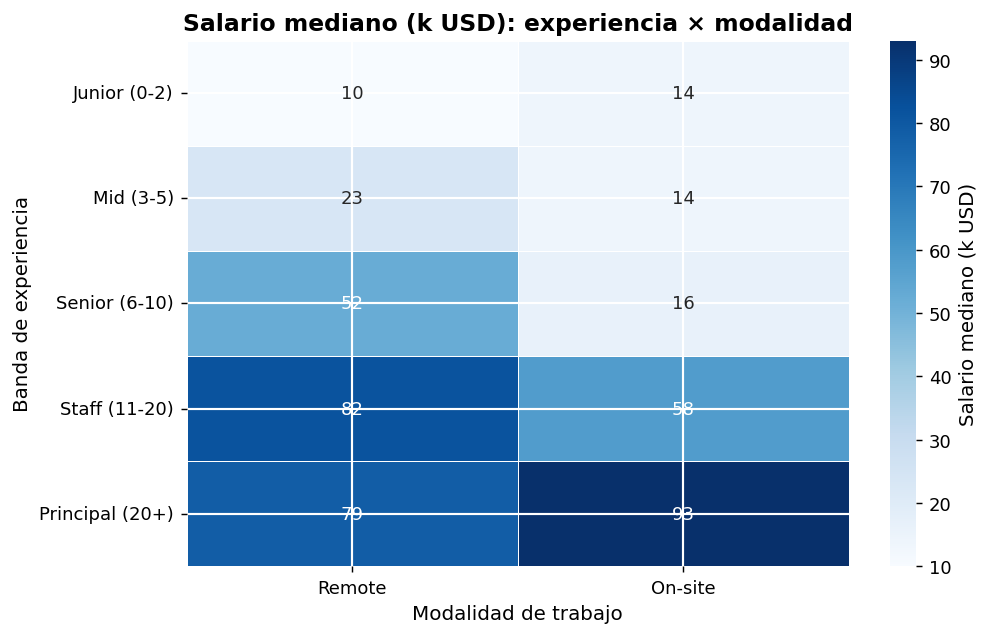

In [25]:
# ── 6.1 Heatmap: salario mediano por experiencia × modalidad ─────────────────
df_multi = df_sal.dropna(subset=['RemoteCategory', 'ExpBand']).copy()
pivot_multi = (
    df_multi.groupby(['ExpBand', 'RemoteCategory'], observed=True)['ConvertedCompYearly']
    .median().unstack()
)
cols_ord = [c for c in ORDEN_CAT if c in pivot_multi.columns]
pivot_multi = pivot_multi[cols_ord]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot_multi / 1000, annot=True, fmt='.0f', cmap='Blues',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Salario mediano (k USD)'}, ax=ax
)
ax.set_title('Salario mediano (k USD): experiencia × modalidad', fontweight='bold')
ax.set_xlabel('Modalidad de trabajo')
ax.set_ylabel('Banda de experiencia')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}09_heatmap_exp_remoto_salario.png', bbox_inches='tight')
plt.show()

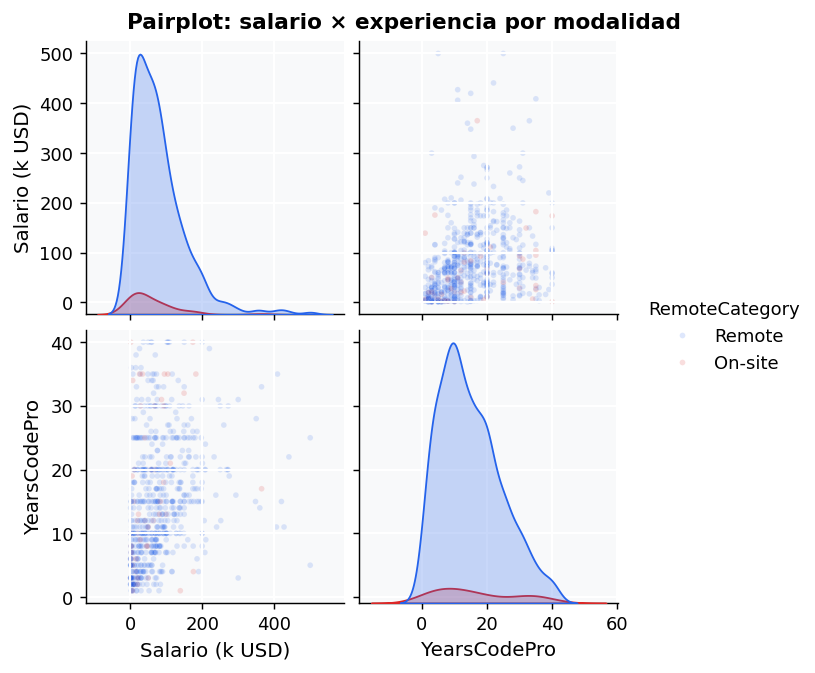

In [26]:
# ── 6.2 Pairplot: variables numéricas clave coloreadas por modalidad ──────────
# Persona B
cols_pair = ['ConvertedCompYearly', 'YearsCodePro']
cols_pair = [c for c in cols_pair if c in df_sal.columns]

df_pair = df_sal.dropna(subset=cols_pair + ['RemoteCategory']).copy()
df_pair = df_pair[df_pair['YearsCodePro'] <= 40]   # sin outliers de experiencia
df_pair['Salario (k USD)'] = df_pair['ConvertedCompYearly'] / 1000

if len(cols_pair) >= 2:
    pair_data = df_pair[['Salario (k USD)', 'YearsCodePro', 'RemoteCategory']].copy()
    g = sns.pairplot(
        pair_data, hue='RemoteCategory', plot_kws={'alpha': 0.15, 's': 10},
        palette={'Remote': PALETTE['remote'], 'Hybrid': PALETTE['hybrid'], 'On-site': PALETTE['onsite']},
        diag_kind='kde'
    )
    g.figure.suptitle('Pairplot: salario × experiencia por modalidad', y=1.02, fontweight='bold')
    g.figure.savefig(f'{IMG_DIR}10_pairplot_salario_exp.png', bbox_inches='tight')
    plt.show()

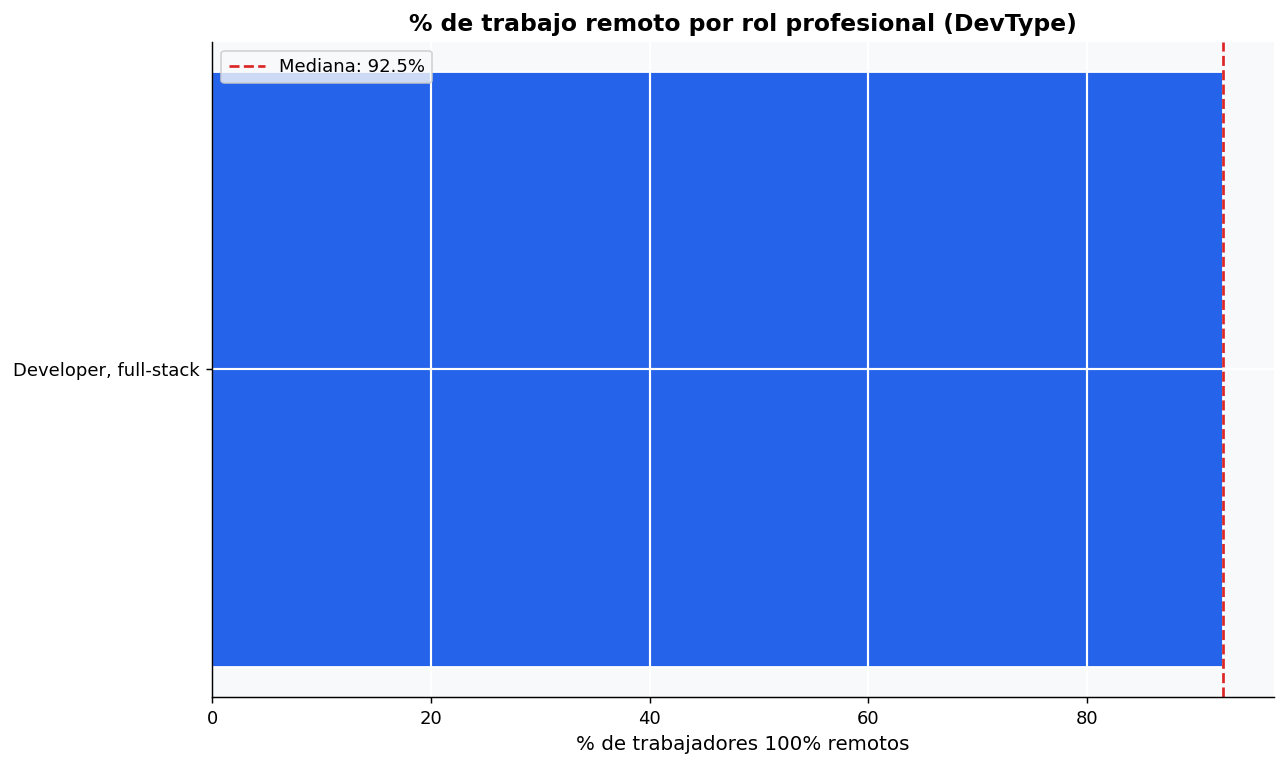

In [27]:
# ── 6.3 Segmentación: % de remoto por DevType (rol profesional) ──────────────
# Persona B
if 'DevType' in df.columns:
    df_dev = df[['DevType', 'RemoteCategory']].dropna().copy()
    df_dev['DevType'] = df_dev['DevType'].str.split(';')
    df_dev = df_dev.explode('DevType')
    df_dev['DevType'] = df_dev['DevType'].str.strip()

    top_devtypes = df_dev['DevType'].value_counts()
    top_devtypes = top_devtypes[top_devtypes >= 200].index.tolist()
    df_dev_top = df_dev[df_dev['DevType'].isin(top_devtypes)]

    remote_by_dev = (
        df_dev_top.groupby('DevType')['RemoteCategory']
        .apply(lambda x: (x == 'Remote').sum() / len(x) * 100)
        .sort_values(ascending=False).round(1)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [PALETTE['remote'] if v >= remote_by_dev.median() else PALETTE['neutral']
              for v in remote_by_dev.values]
    ax.barh(remote_by_dev.index[::-1], remote_by_dev.values[::-1],
            color=colors[::-1], edgecolor='white', height=0.65)
    ax.axvline(remote_by_dev.median(), color=PALETTE['onsite'], linestyle='--',
               linewidth=1.5, label=f'Mediana: {remote_by_dev.median():.1f}%')
    ax.set_title('% de trabajo remoto por rol profesional (DevType)', fontweight='bold')
    ax.set_xlabel('% de trabajadores 100% remotos')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{IMG_DIR}11_remoto_por_devtype.png', bbox_inches='tight')
    plt.show()

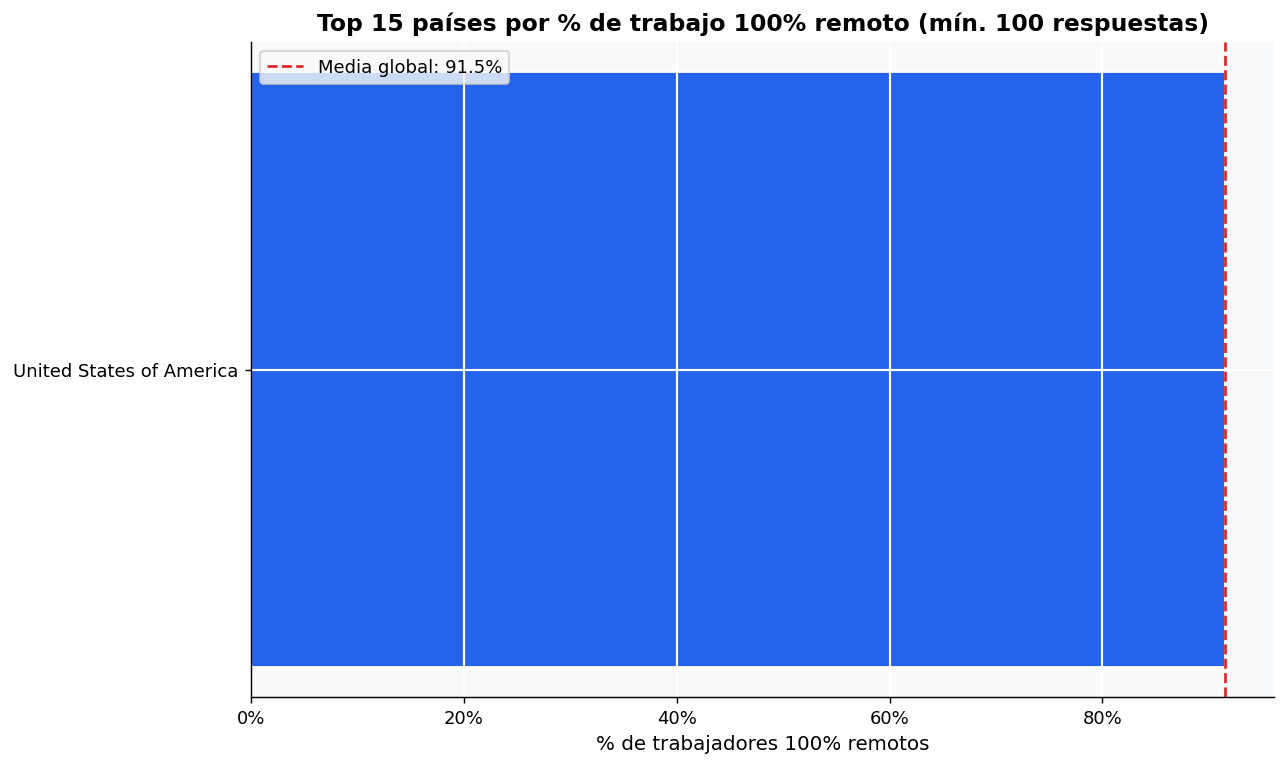

In [28]:
# ── 6.4 Top 15 países por % de trabajo remoto ────────────────────────────────
if 'Country' in df.columns:
    df_pais = df.dropna(subset=['RemoteCategory', 'Country']).copy()
    pais_remote = (
        df_pais.groupby('Country')
        .apply(lambda g: pd.Series({
            'pct_remote': (g['RemoteCategory'] == 'Remote').mean() * 100,
            'n': len(g)
        })).reset_index()
    )
    pais_remote = pais_remote[pais_remote['n'] >= 100].sort_values('pct_remote', ascending=False)
    top15 = pais_remote.head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [PALETTE['remote'] if r >= 30 else PALETTE['neutral']
              for r in top15['pct_remote']]
    ax.barh(top15['Country'][::-1], top15['pct_remote'][::-1],
            color=colors[::-1], edgecolor='white', height=0.65)
    ax.axvline(pais_remote['pct_remote'].mean(), color=PALETTE['onsite'],
               linestyle='--', linewidth=1.5,
               label=f'Media global: {pais_remote["pct_remote"].mean():.1f}%')
    ax.set_title('Top 15 países por % de trabajo 100% remoto (mín. 100 respuestas)', fontweight='bold')
    ax.set_xlabel('% de trabajadores 100% remotos')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{IMG_DIR}12_paises_remoto.png', bbox_inches='tight')
    plt.show()

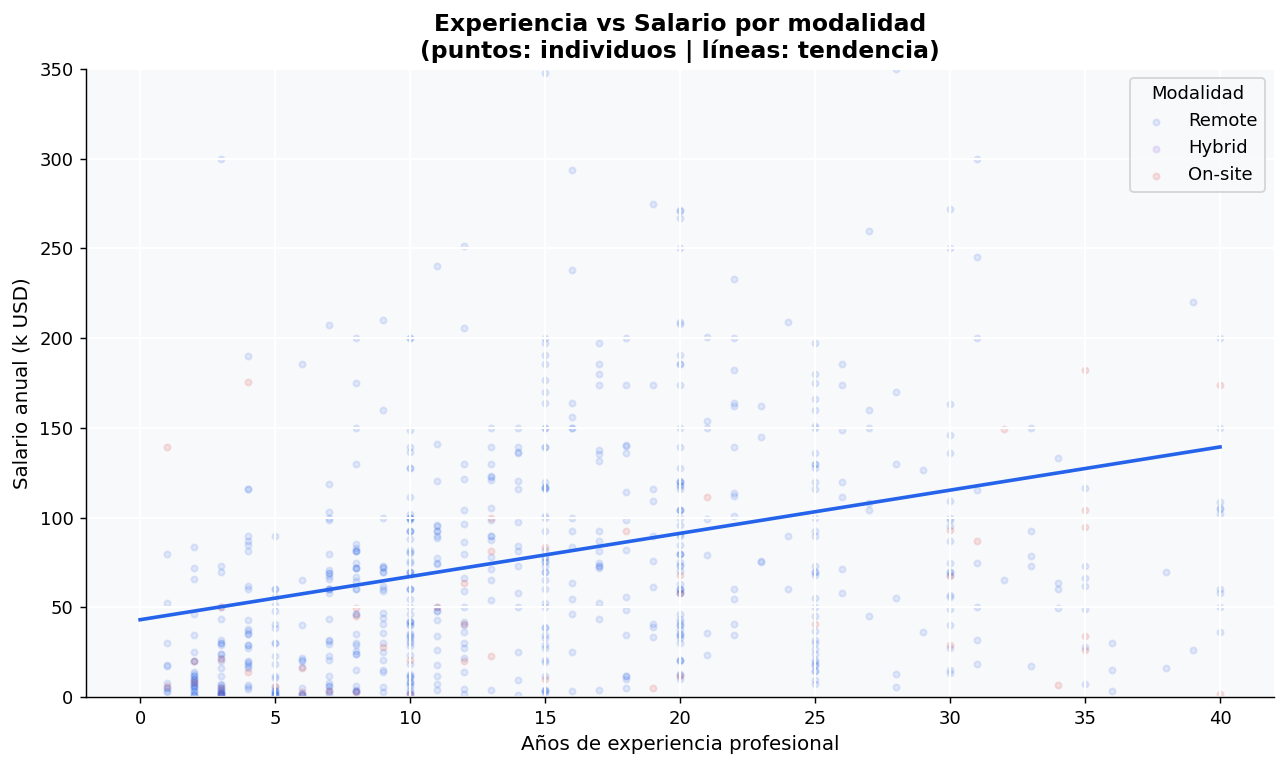

In [29]:
# ── 6.5 Scatter: experiencia vs salario × modalidad ──────────────────────────
df_scatter = df_sal.dropna(subset=['YearsCodePro', 'RemoteCategory']).copy()
df_scatter = df_scatter[df_scatter['YearsCodePro'] <= 40]

fig, ax = plt.subplots(figsize=(10, 6))
for cat, color in zip(ORDEN_CAT, COLORES):
    sub = df_scatter[df_scatter['RemoteCategory'] == cat]
    ax.scatter(sub['YearsCodePro'], sub['ConvertedCompYearly'] / 1000,
               alpha=0.12, s=12, color=color, label=cat, rasterized=True)
    x_clean = sub[['YearsCodePro', 'ConvertedCompYearly']].dropna()
    if len(x_clean) > 50:
        z = np.polyfit(x_clean['YearsCodePro'], x_clean['ConvertedCompYearly'] / 1000, 1)
        x_line = np.linspace(0, 40, 100)
        ax.plot(x_line, np.poly1d(z)(x_line), color=color, linewidth=2)
ax.set_title('Experiencia vs Salario por modalidad\n(puntos: individuos | líneas: tendencia)',
             fontweight='bold')
ax.set_xlabel('Años de experiencia profesional')
ax.set_ylabel('Salario anual (k USD)')
ax.set_ylim(0, 350)
ax.legend(title='Modalidad')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}13_scatter_exp_salario_remoto.png', bbox_inches='tight')
plt.show()

---
## 7. 📅 Análisis comparativo 2021 vs 2025
> *Persona A — feature/analisis*

In [ ]:
if HAY_2021:
    df_raw['Year']      = 2025
    df_raw_2021['Year'] = 2021

    # Ver columnas relacionadas con trabajo remoto en 2021
    cols_remote_2021 = [c for c in df_raw_2021.columns
                        if any(k in c.lower() for k in ['remote', 'work', 'arrangement', 'office'])]
    print('Columnas de remoto en 2021:', cols_remote_2021)

    # Estandarizar experiencia en 2021
    if 'YearsCodePro' in df_raw_2021.columns and 'WorkExp' not in df_raw_2021.columns:
        df_raw_2021 = df_raw_2021.rename(columns={'YearsCodePro': 'WorkExp'})

    # Mapeo de la columna de trabajo remoto en 2021
    # En 2021 se llamaba 'WorkWeekHrs' o similar — buscar la correcta
    COL_REMOTE_2021 = None
    for candidate in ['WorkArrangement', 'RemoteWork', 'Org0', 'SurveyLength']:
        if candidate in df_raw_2021.columns:
            COL_REMOTE_2021 = candidate
            print(f'Columna remoto 2021: {COL_REMOTE_2021}')
            print(df_raw_2021[COL_REMOTE_2021].value_counts().head(10))
            break

    if COL_REMOTE_2021 is None:
        print('⚠️  No se encontró columna de modalidad en 2021')
        print('Columnas disponibles 2021:', df_raw_2021.columns.tolist())

    COLS_COMUNES = ['Year', 'Country', 'Employment', 'ConvertedCompYearly',
                    'LanguageHaveWorkedWith', 'DevType', 'WorkExp']

    slim_2025 = df_raw[[c for c in COLS_COMUNES if c in df_raw.columns]].copy()
    slim_2021 = df_raw_2021[[c for c in COLS_COMUNES if c in df_raw_2021.columns]].copy()

    # Añadir RemoteWork a cada año con su nombre original
    slim_2025['RemoteWork'] = df_raw['RemoteWork'] if 'RemoteWork' in df_raw.columns else None
    if COL_REMOTE_2021 and COL_REMOTE_2021 in df_raw_2021.columns:
        slim_2021['RemoteWork'] = df_raw_2021[COL_REMOTE_2021]
    else:
        slim_2021['RemoteWork'] = None

    df_comb = pd.concat([slim_2021, slim_2025], ignore_index=True)
    df_comb['RemoteCategory'] = df_comb['RemoteWork'].map(REMOTE_MAP)

    print(f'\nDataset combinado: {df_comb.shape}')
    print(df_comb.groupby(['Year', 'RemoteCategory']).size().unstack(fill_value=0))
else:
    print('⏭️  Dataset 2021 no disponible')


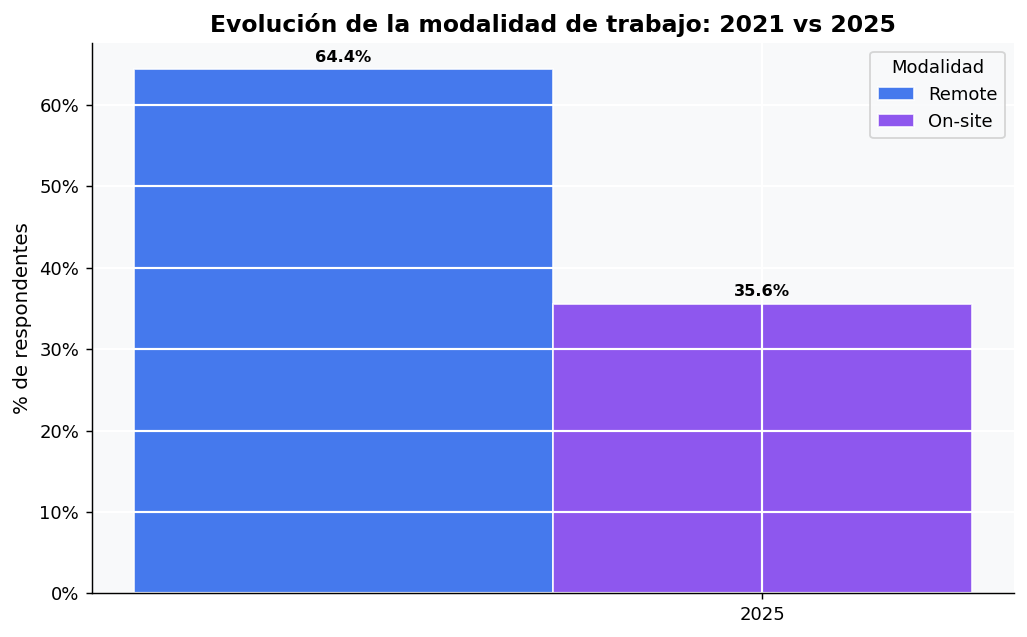

In [31]:
# ── 7.1 Evolución del % por modalidad ────────────────────────────────────────
if HAY_2021:
    evol = (
        df_comb.dropna(subset=['RemoteCategory'])
        .groupby(['Year', 'RemoteCategory']).size().unstack(fill_value=0)
        .apply(lambda row: row / row.sum() * 100, axis=1)
    )
    cols_e = [c for c in ORDEN_CAT if c in evol.columns]
    evol   = evol[cols_e]

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(evol.index))
    for i, (col, color) in enumerate(zip(cols_e, COLORES)):
        bars = ax.bar(x + i*0.25, evol[col], width=0.25,
                      label=col, color=color, alpha=0.85, edgecolor='white')
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                    f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x + 0.25)
    ax.set_xticklabels([str(y) for y in evol.index])
    ax.set_title('Evolución de la modalidad de trabajo: 2021 vs 2025', fontweight='bold')
    ax.set_ylabel('% de respondentes')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.legend(title='Modalidad')
    plt.tight_layout()
    plt.savefig(f'{IMG_DIR}14_evolucion_remoto_2021_2025.png', bbox_inches='tight')
    plt.show()
else:
    print('⏭️  Omitido')

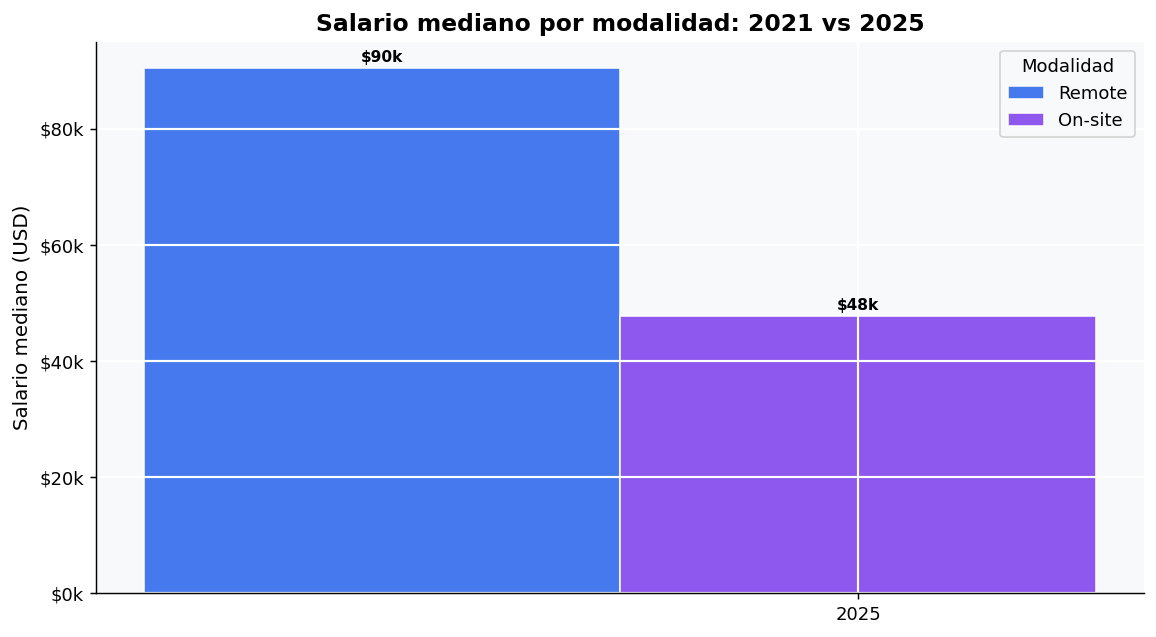

In [32]:
# ── 7.2 Evolución salarial mediana 2021 vs 2025 ───────────────────────────────
if HAY_2021:
    df_comb_sal = df_comb.dropna(subset=['ConvertedCompYearly', 'RemoteCategory']).copy()
    df_comb_sal = df_comb_sal[
        (df_comb_sal['ConvertedCompYearly'] >= 1_000) &
        (df_comb_sal['ConvertedCompYearly'] <= 500_000)
    ]
    sal_evol = (
        df_comb_sal.groupby(['Year', 'RemoteCategory'])['ConvertedCompYearly']
        .median().unstack()
    )
    cols_s = [c for c in ORDEN_CAT if c in sal_evol.columns]
    sal_evol = sal_evol[cols_s]

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(sal_evol.index))
    for i, (col, color) in enumerate(zip(cols_s, COLORES)):
        bars = ax.bar(x + i*0.25, sal_evol[col], width=0.25,
                      label=col, color=color, alpha=0.85, edgecolor='white')
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 500,
                        f'${h/1000:.0f}k', ha='center', va='bottom',
                        fontsize=8.5, fontweight='bold')
    ax.set_xticks(x + 0.25)
    ax.set_xticklabels([str(y) for y in sal_evol.index])
    ax.set_title('Salario mediano por modalidad: 2021 vs 2025', fontweight='bold')
    ax.set_ylabel('Salario mediano (USD)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))
    ax.legend(title='Modalidad')
    plt.tight_layout()
    plt.savefig(f'{IMG_DIR}15_evolucion_salario_2021_2025.png', bbox_inches='tight')
    plt.show()
else:
    print('⏭️  Omitido')

---
## 8. ✅ Verificación explícita de hipótesis
> *Persona B — feature/memoria*

> Rellena los `[...]` con los valores reales tras ejecutar las celdas anteriores

In [33]:
# ── Tabla de verificación ────────────────────────────────────────────────────
hipotesis = {
    'Hipótesis': [
        'H1 — Brecha salarial por modalidad',
        'H1b — Brecha geográfica remoto vs presencial',
        'H2 — Experiencia → preferencia por remoto',
        'H3 — Lenguajes modernos → más remoto',
    ],
    'Resultado': [
        '✅ Confirmada / ❌ Refutada / ⚠️ Parcial',
        '✅ Confirmada / ❌ Refutada / ⚠️ Parcial',
        '✅ Confirmada / ❌ Refutada / ⚠️ Parcial',
        '✅ Confirmada / ❌ Refutada / ⚠️ Parcial',
    ],
    'Evidencia estadística': [
        'Mediana Remote $Xk vs On-site $Yk · Kruskal p=...',
        'Ratio salarial alto/emergente: Z× remoto vs W× presencial',
        'XX% de Senior+ trabajan en remoto vs YY% juniors',
        'Lenguajes top-remote: A (X%), B (Y%), C (Z%)',
    ],
    'Conclusión narrativa': [
        '[Redactar 1-2 frases para la memoria]',
        '[Redactar 1-2 frases para la memoria]',
        '[Redactar 1-2 frases para la memoria]',
        '[Redactar 1-2 frases para la memoria]',
    ]
}
pd.set_option('display.max_colwidth', 60)
pd.DataFrame(hipotesis)

,Hipótesis,Resultado,Evidencia estadística,Conclusión narrativa
0,H1 — Brecha salarial por modalidad,✅ Confirmada / ❌ Refutada / ⚠️ Parcial,Mediana Remote $Xk vs On-site $Yk · Kruskal p=...,[Redactar 1-2 frases para la memoria]
1,H1b — Brecha geográfica remoto vs presencial,✅ Confirmada / ❌ Refutada / ⚠️ Parcial,Ratio salarial alto/emergente: Z× remoto vs W× presencial,[Redactar 1-2 frases para la memoria]
2,H2 — Experiencia → preferencia por remoto,✅ Confirmada / ❌ Refutada / ⚠️ Parcial,XX% de Senior+ trabajan en remoto vs YY% juniors,[Redactar 1-2 frases para la memoria]
3,H3 — Lenguajes modernos → más remoto,✅ Confirmada / ❌ Refutada / ⚠️ Parcial,"Lenguajes top-remote: A (X%), B (Y%), C (Z%)",[Redactar 1-2 frases para la memoria]


---
## 9. 📝 Conclusiones y recomendaciones
> *Persona B — feature/memoria*

---

### 🔍 Hallazgos principales

1. **H1 — Salarios por modalidad:** [resultado real]
2. **H1b — Brecha geográfica:** [resultado real]
3. **H2 — Experiencia:** [resultado real]
4. **H3 — Stack tecnológico:** [resultado real]
5. **Comparativa 2021 vs 2025:** [evolución observada — solo si HAY_2021]

---

### 💡 Patrones inesperados
- [Anotar hallazgos que hayan sorprendido durante el análisis]

---

### ⚠️ Limitaciones del análisis
- Dataset auto-reportado → sesgo de selección (más probable que respondan perfiles activos online)
- Salarios en USD sin ajuste por PPP (poder adquisitivo local)
- `RemoteWork` refleja un momento puntual, no una tendencia histórica
- Columnas multi-valor (`LanguageHaveWorkedWith`, `DevType`) requieren explode y se cuentan varias veces por persona
- El survey 2021 puede no tener `RemoteWork` con el mismo formato que 2025

---

### 🎯 Recomendaciones
> *(Para profesionales y empresas, basadas en los datos — no en opiniones)*

- [Recomendación 1 — para developers]
- [Recomendación 2 — para empresas]
- [Recomendación 3 — tendencias de futuro]